<a href="https://colab.research.google.com/github/umeshpandeybtech/BusinessAnalytics/blob/master/ML_With_Different_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()

print(data)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [ ]:
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [ ]:
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

In [ ]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
df["target"] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


np.int64(0)

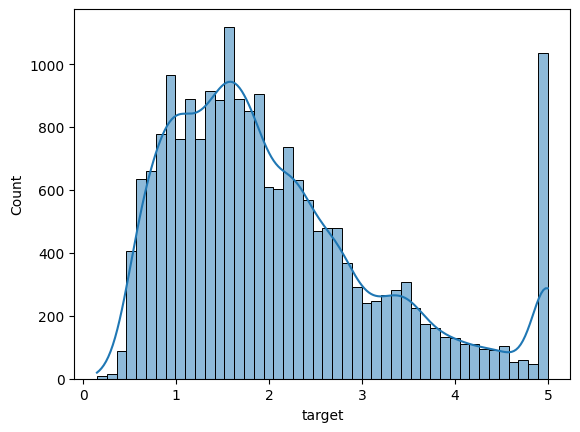

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["target"], kde=True)
plt.show()

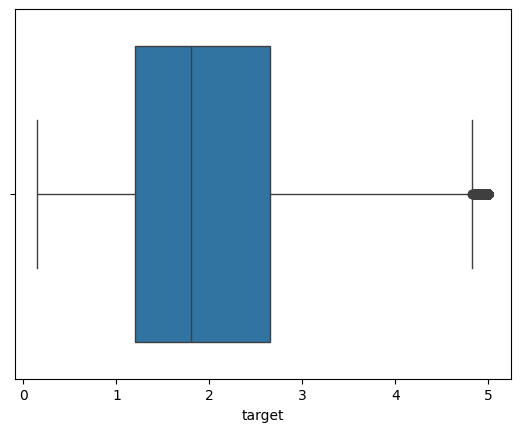

In [ ]:
sns.boxplot(x=df["target"])
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
import numpy as np

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(name)
    print("R2:", r2_score(y_test, y_pred))

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print("RMSE:", rmse)
    print()

Linear Regression
R2: 0.5757877060324508
RMSE: 0.7455813830127764

Decision Tree
R2: 0.622075845135081
RMSE: 0.7037294974840077

Random Forest
R2: 0.8051230593157366
RMSE: 0.5053399773665033



In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr
import pandas as pd


def predict_house(
    model_name,
    MedInc,
    HouseAge,
    AveRooms,
    AveBedrms,
    Population,
    AveOccup,
    Latitude,
    Longitude
):

    # Create input DataFrame
    input_data = pd.DataFrame({
        "MedInc": [MedInc],
        "HouseAge": [HouseAge],
        "AveRooms": [AveRooms],
        "AveBedrms": [AveBedrms],
        "Population": [Population],
        "AveOccup": [AveOccup],
        "Latitude": [Latitude],
        "Longitude": [Longitude]
    })

    # Select model
    model = models[model_name]

    # Prediction
    prediction = model.predict(input_data)[0]

    return f"${prediction:.2f}"

In [ ]:
demo = gr.Interface(
    fn=predict_house,

    inputs=[
        gr.Dropdown(
            choices=[
                "Linear Regression",
                "Decision Tree",
                "Random Forest"
            ],
            value="Random Forest",
            label="Select Model"
        ),

        gr.Number(
            value=5.0,
            label="Median Income"
        ),

        gr.Number(
            value=20.0,
            label="House Age"
        ),

        gr.Number(
            value=5.0,
            label="Average Rooms"
        ),

        gr.Number(
            value=1.0,
            label="Average Bedrooms"
        ),

        gr.Number(
            value=1000.0,
            label="Population"
        ),

        gr.Number(
            value=3.0,
            label="Average Occupancy"
        ),

        gr.Number(
            value=35.0,
            label="Latitude"
        ),

        gr.Number(
            value=-120.0,
            label="Longitude"
        )
    ],

    outputs=gr.Textbox(
        label="Predicted House Value"
    ),

    title="🏠 California Housing Price Predictor",

    description=(
        "Enter housing information and select a "
        "machine learning model to predict the house value."
    )
)

In [ ]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://821c167650c8b8e99d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
